In [1]:
#import librearies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
#load datasets
datasets = {
    'steel-plates-fault': fetch_openml(name='steel-plates-fault', version=1, as_frame=False),
    'ionosphere': fetch_openml(name='ionosphere', version=1, as_frame=False),
    'banknote-authentication': fetch_openml(name='banknote-authentication', version=1, as_frame=False)
}

In [3]:
#classifiers and hyperparameters
classifiers = {
    "KNeighborsClassifier": {
        "model": KNeighborsClassifier(),
        "param_name": "n_neighbors",
        "param_range": [1, 2, 3, 4, 5]
    },
    "GaussianNB": {
        "model": GaussianNB(),
        "param_name": "var_smoothing",
        "param_range": [1e-9, 1e-5, 0.1]
    },
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=1000),
        "param_name": "C",
        "param_range": [0.1, 0.5, 1.0, 2.0, 5.0]
    },
    "DecisionTreeClassifier": {
        "model": DecisionTreeClassifier(),
        "param_name": "max_depth",
        "param_range": [1, 3, 5, 8, 10]
    },
    "GradientBoostingClassifier": {
        "model": GradientBoostingClassifier(),
        "param_name": "max_depth",
        "param_range": [1, 3, 5, 8, 10]
    },
    "RandomForestClassifier": {
        "model": RandomForestClassifier(),
        "param_name": "max_depth",
        "param_range": [1, 3, 5, 8, 10]
    },
    "MLPClassifier": {
        "model": MLPClassifier(max_iter=1000),
        "param_name": "alpha",
        "param_range": [1e-5, 1e-3, 0.1, 10.0]
    }
}

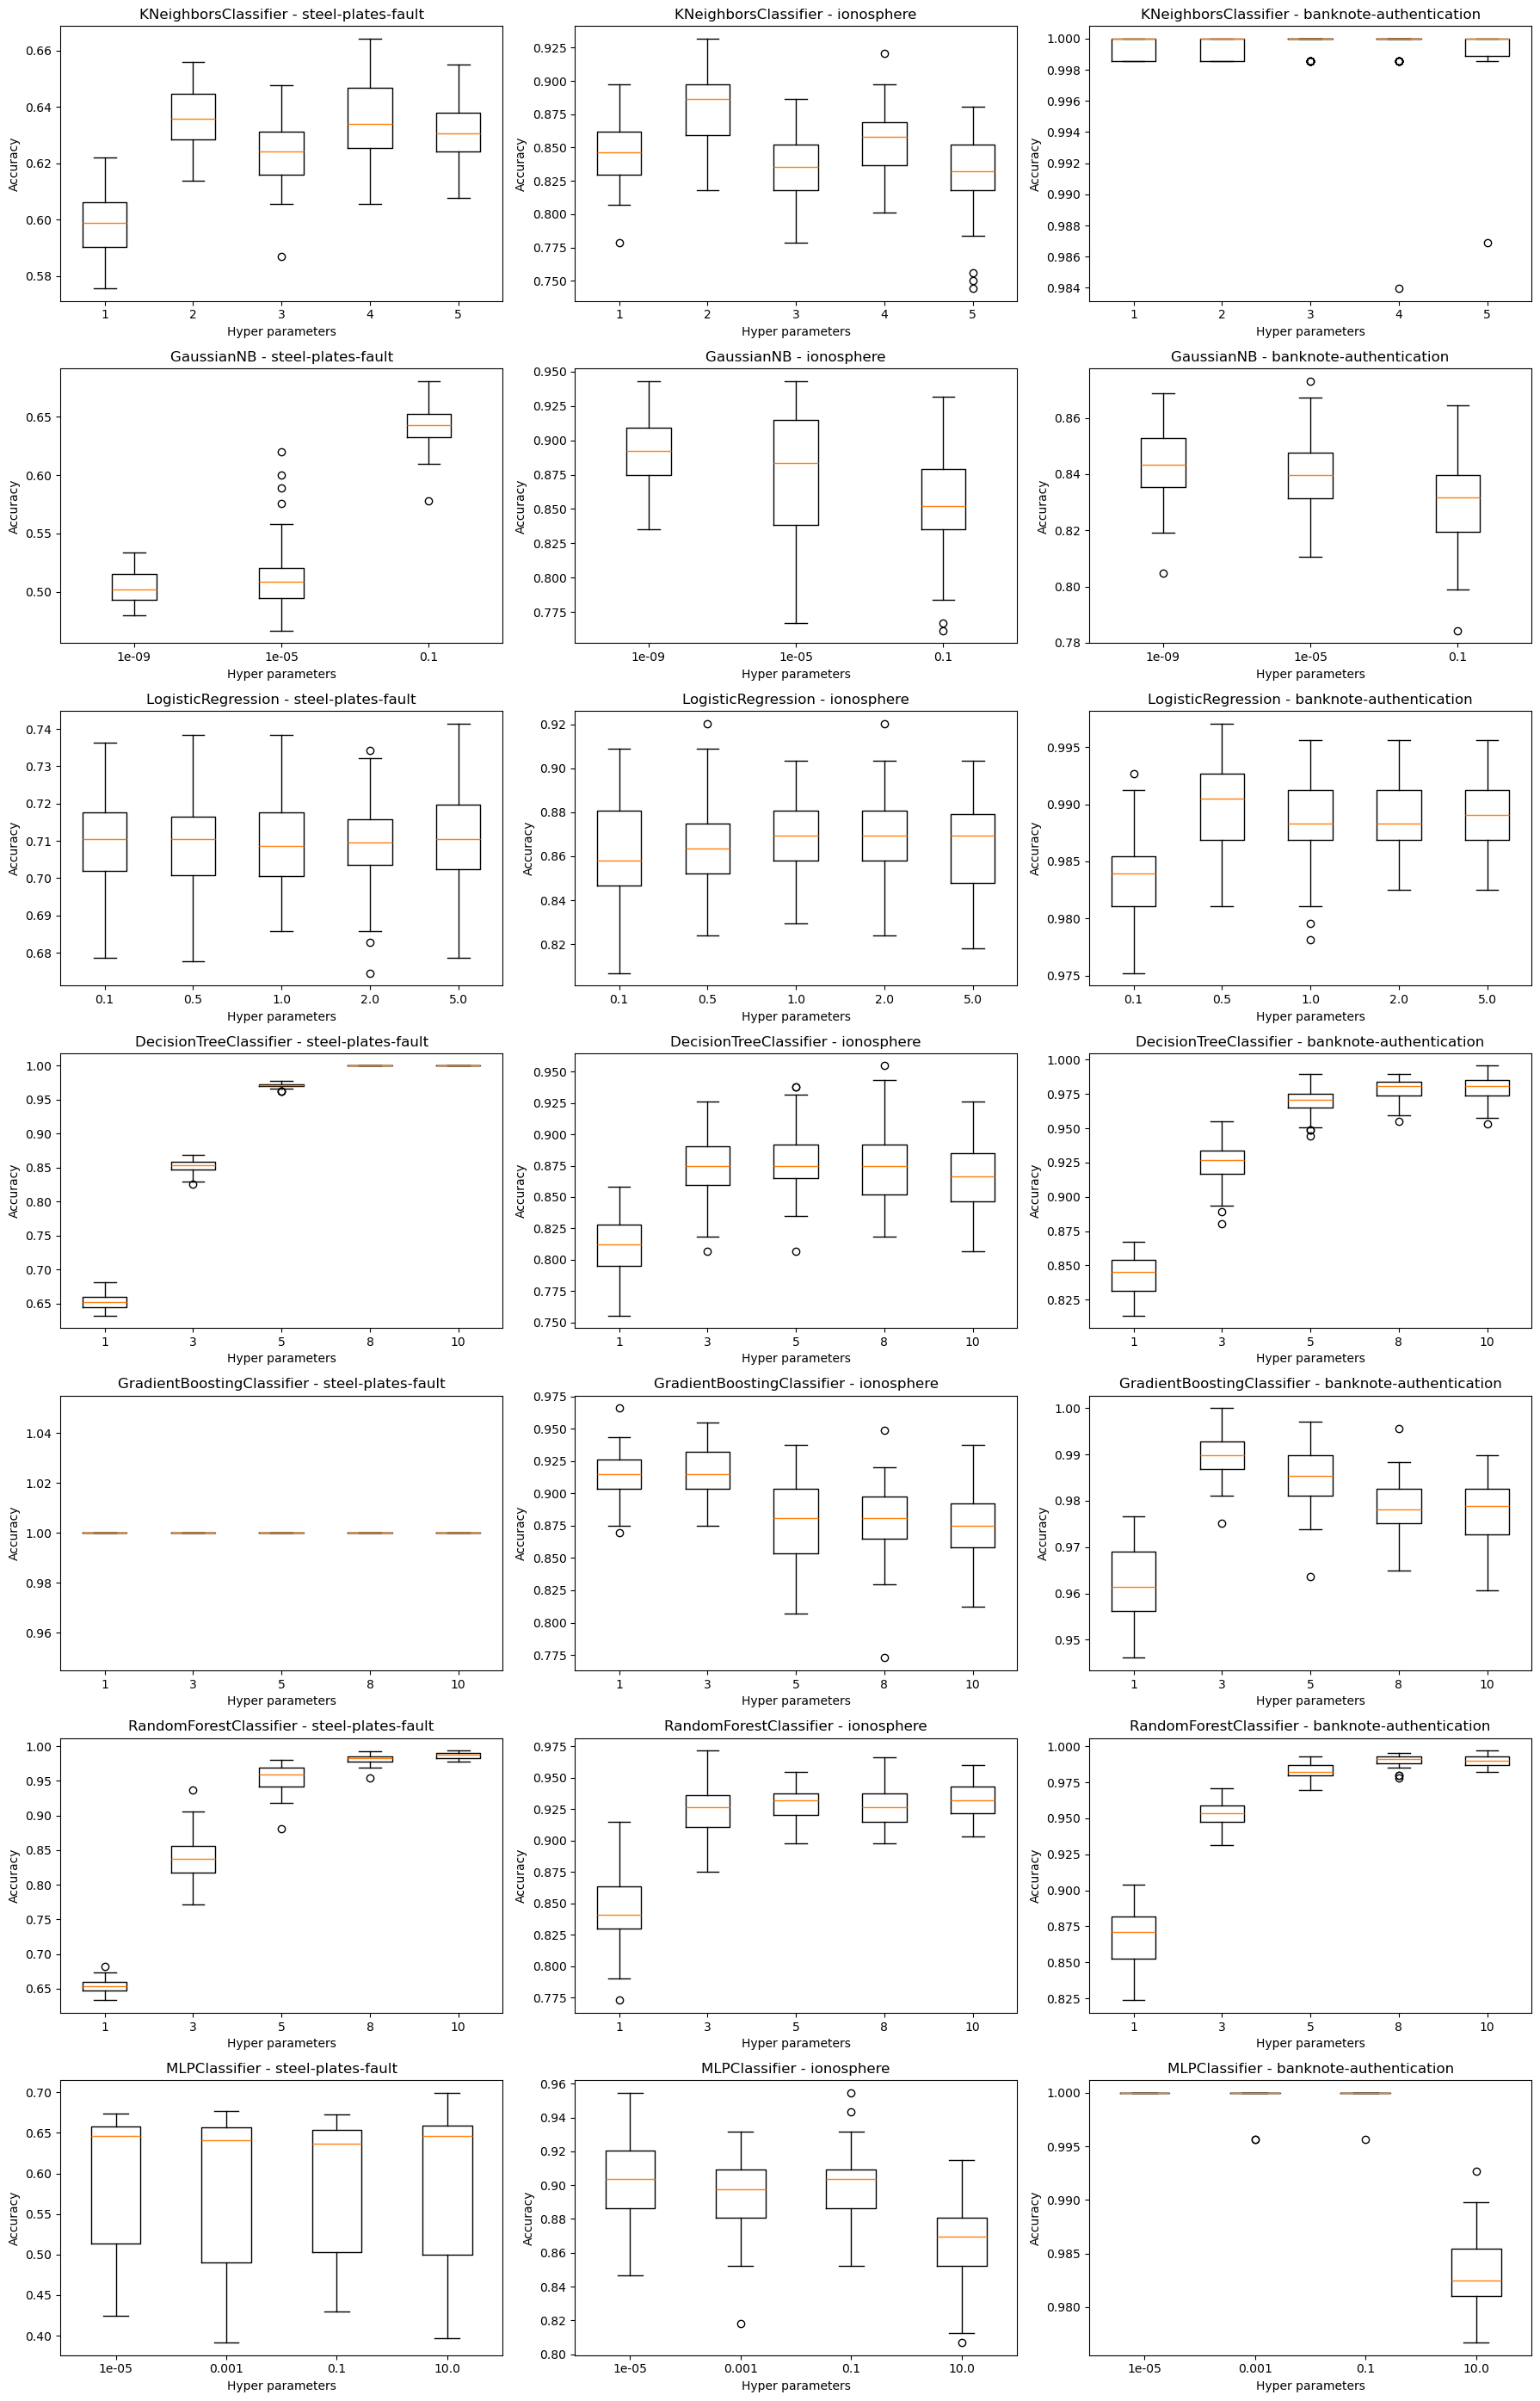

<Figure size 640x480 with 0 Axes>

In [4]:
fig, axes = plt.subplots(len(classifiers), len(datasets), figsize=(18, 28))
fig.subplots_adjust(hspace=0.5)

#set seed
seed = np.random.seed(42)

#loop through classifiers and datasets
for clf_idx, (clf_name, clf_info) in enumerate(classifiers.items()):
    for ds_idx, (ds_name, dataset) in enumerate(datasets.items()):
        X, y = dataset.data, dataset.target
        accuracies = []

        #loop through each hyperparameter 
        for param_value in clf_info["param_range"]:
            temp_accuracies = []
            
            #50 iterations
            for _ in range(50):
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=seed)
                model = clf_info["model"].set_params(**{clf_info["param_name"]: param_value})
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                temp_accuracies.append(accuracy_score(y_test, y_pred))
            
            accuracies.append(temp_accuracies)
        
        #plot
        axes[clf_idx, ds_idx].boxplot(accuracies)
        axes[clf_idx, ds_idx].set_title(f"{clf_name} - {ds_name}")
        axes[clf_idx, ds_idx].set_xlabel("Hyper parameters")
        axes[clf_idx, ds_idx].set_ylabel("Accuracy")
        axes[clf_idx, ds_idx].set_xticklabels(clf_info["param_range"])

#display the plots
plt.tight_layout()
plt.show()
#save the plots
plt.savefig('boxplot.png')

In [5]:
#initilize results in order to store best mean error and best param value
results = {clf_name: {ds_name: {'best_mean_error': np.inf, 'best_param_value': None} for ds_name in datasets.keys()} for clf_name in classifiers.keys()}

#loop through classifiers and datasets
for clf_idx, (clf_name, clf_info) in enumerate(classifiers.items()):
    for ds_idx, (ds_name, dataset) in enumerate(datasets.items()):
        X, y = dataset.data, dataset.target
        accuracies = []

        #loop through hyper parameters
        for param_value in clf_info["param_range"]:
            temp_accuracies = []
            
            #50 iterations
            for _ in range(50):
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=seed)
                model = clf_info["model"].set_params(**{clf_info["param_name"]: param_value})
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                temp_accuracies.append(accuracy_score(y_test, y_pred))
            
            accuracies.append(temp_accuracies)
            #mean error
            mean_error = 1 - np.mean(temp_accuracies)

            #update to find best mean error and param
            if mean_error < results[clf_name][ds_name]['best_mean_error']:
                results[clf_name][ds_name]['best_mean_error'] = mean_error
                results[clf_name][ds_name]['best_param_value'] = param_value
#summary tables
summary_table_1 = pd.DataFrame({ds_name: {clf_name: results[clf_name][ds_name]['best_mean_error'] for clf_name in classifiers.keys()} for ds_name in datasets.keys()})
summary_table_2 = pd.DataFrame({ds_name: {clf_name: results[clf_name][ds_name]['best_param_value'] for clf_name in classifiers.keys()} for ds_name in datasets.keys()})

#display tables
print("Summary Table 1: Lowest Mean Test Error")
print(summary_table_1)

print("\nSummary Table 2: Corresponding Hyperparameter Values")
print(summary_table_2)

Summary Table 1: Lowest Mean Test Error
                            steel-plates-fault  ionosphere  \
KNeighborsClassifier                  0.357549    0.122045   
GaussianNB                            0.348363    0.114886   
LogisticRegression                    0.289289    0.129205   
DecisionTreeClassifier                0.000000    0.126591   
GradientBoostingClassifier            0.000000    0.081477   
RandomForestClassifier                0.013965    0.068523   
MLPClassifier                         0.370834    0.098409   

                            banknote-authentication  
KNeighborsClassifier                       0.000233  
GaussianNB                                 0.157551  
LogisticRegression                         0.010554  
DecisionTreeClassifier                     0.020350  
GradientBoostingClassifier                 0.009825  
RandomForestClassifier                     0.008746  
MLPClassifier                              0.000000  

Summary Table 2: Corresponding

The overall results captured reveal that different classifiers perform optimally on different datasets. The lowest mean test error for steel-plates-fault is both DecisionTreeClassifier and GradientBoostingClassifier, having a mean test error of 0. Due to the high complexity of these models the risk of this being a result of overfitting is high. However, GradientBoostingClassifier shows consistantly low mean test errors across all the datasets, while DecisionTreeClassifier is not consistantly low mean test error across all. The lowest mean test error for ionosphere is RandomForestClassifier with 0.068523. The lowest mean test error for banknote-authentication is MLPClassifier with 0. Overall the GradientBoostingClassifier and RandomForestClassifier generally exhibit strong performance across all the datasets. This suggests that ensemble methods, which combine the predictions of multiple base models are very effective in capturing the underlying patterns in the datasets. In terms of sensitivity, GaussianNB's performance is highly sensitive to the var_smoothing paramter, with small values yeilding the best results, espicially on the Ionosphere dataset. KNeighborsClassifier shows sensitivity to the n_neighbors parameter where smaller values are preferred, espicially for datasets with distinct clusters like banknote-authentication. DecisionTreeClassifier and RandomForestClassifier appear to be more robust across different hyperparameter settings, although they still acheive optimal perfroamce with specific max_depth values. Overall, the performance of these models is high reliant on careful hyperparamter tuning, which can significantly infulence the model's ability to generalize effectivly.

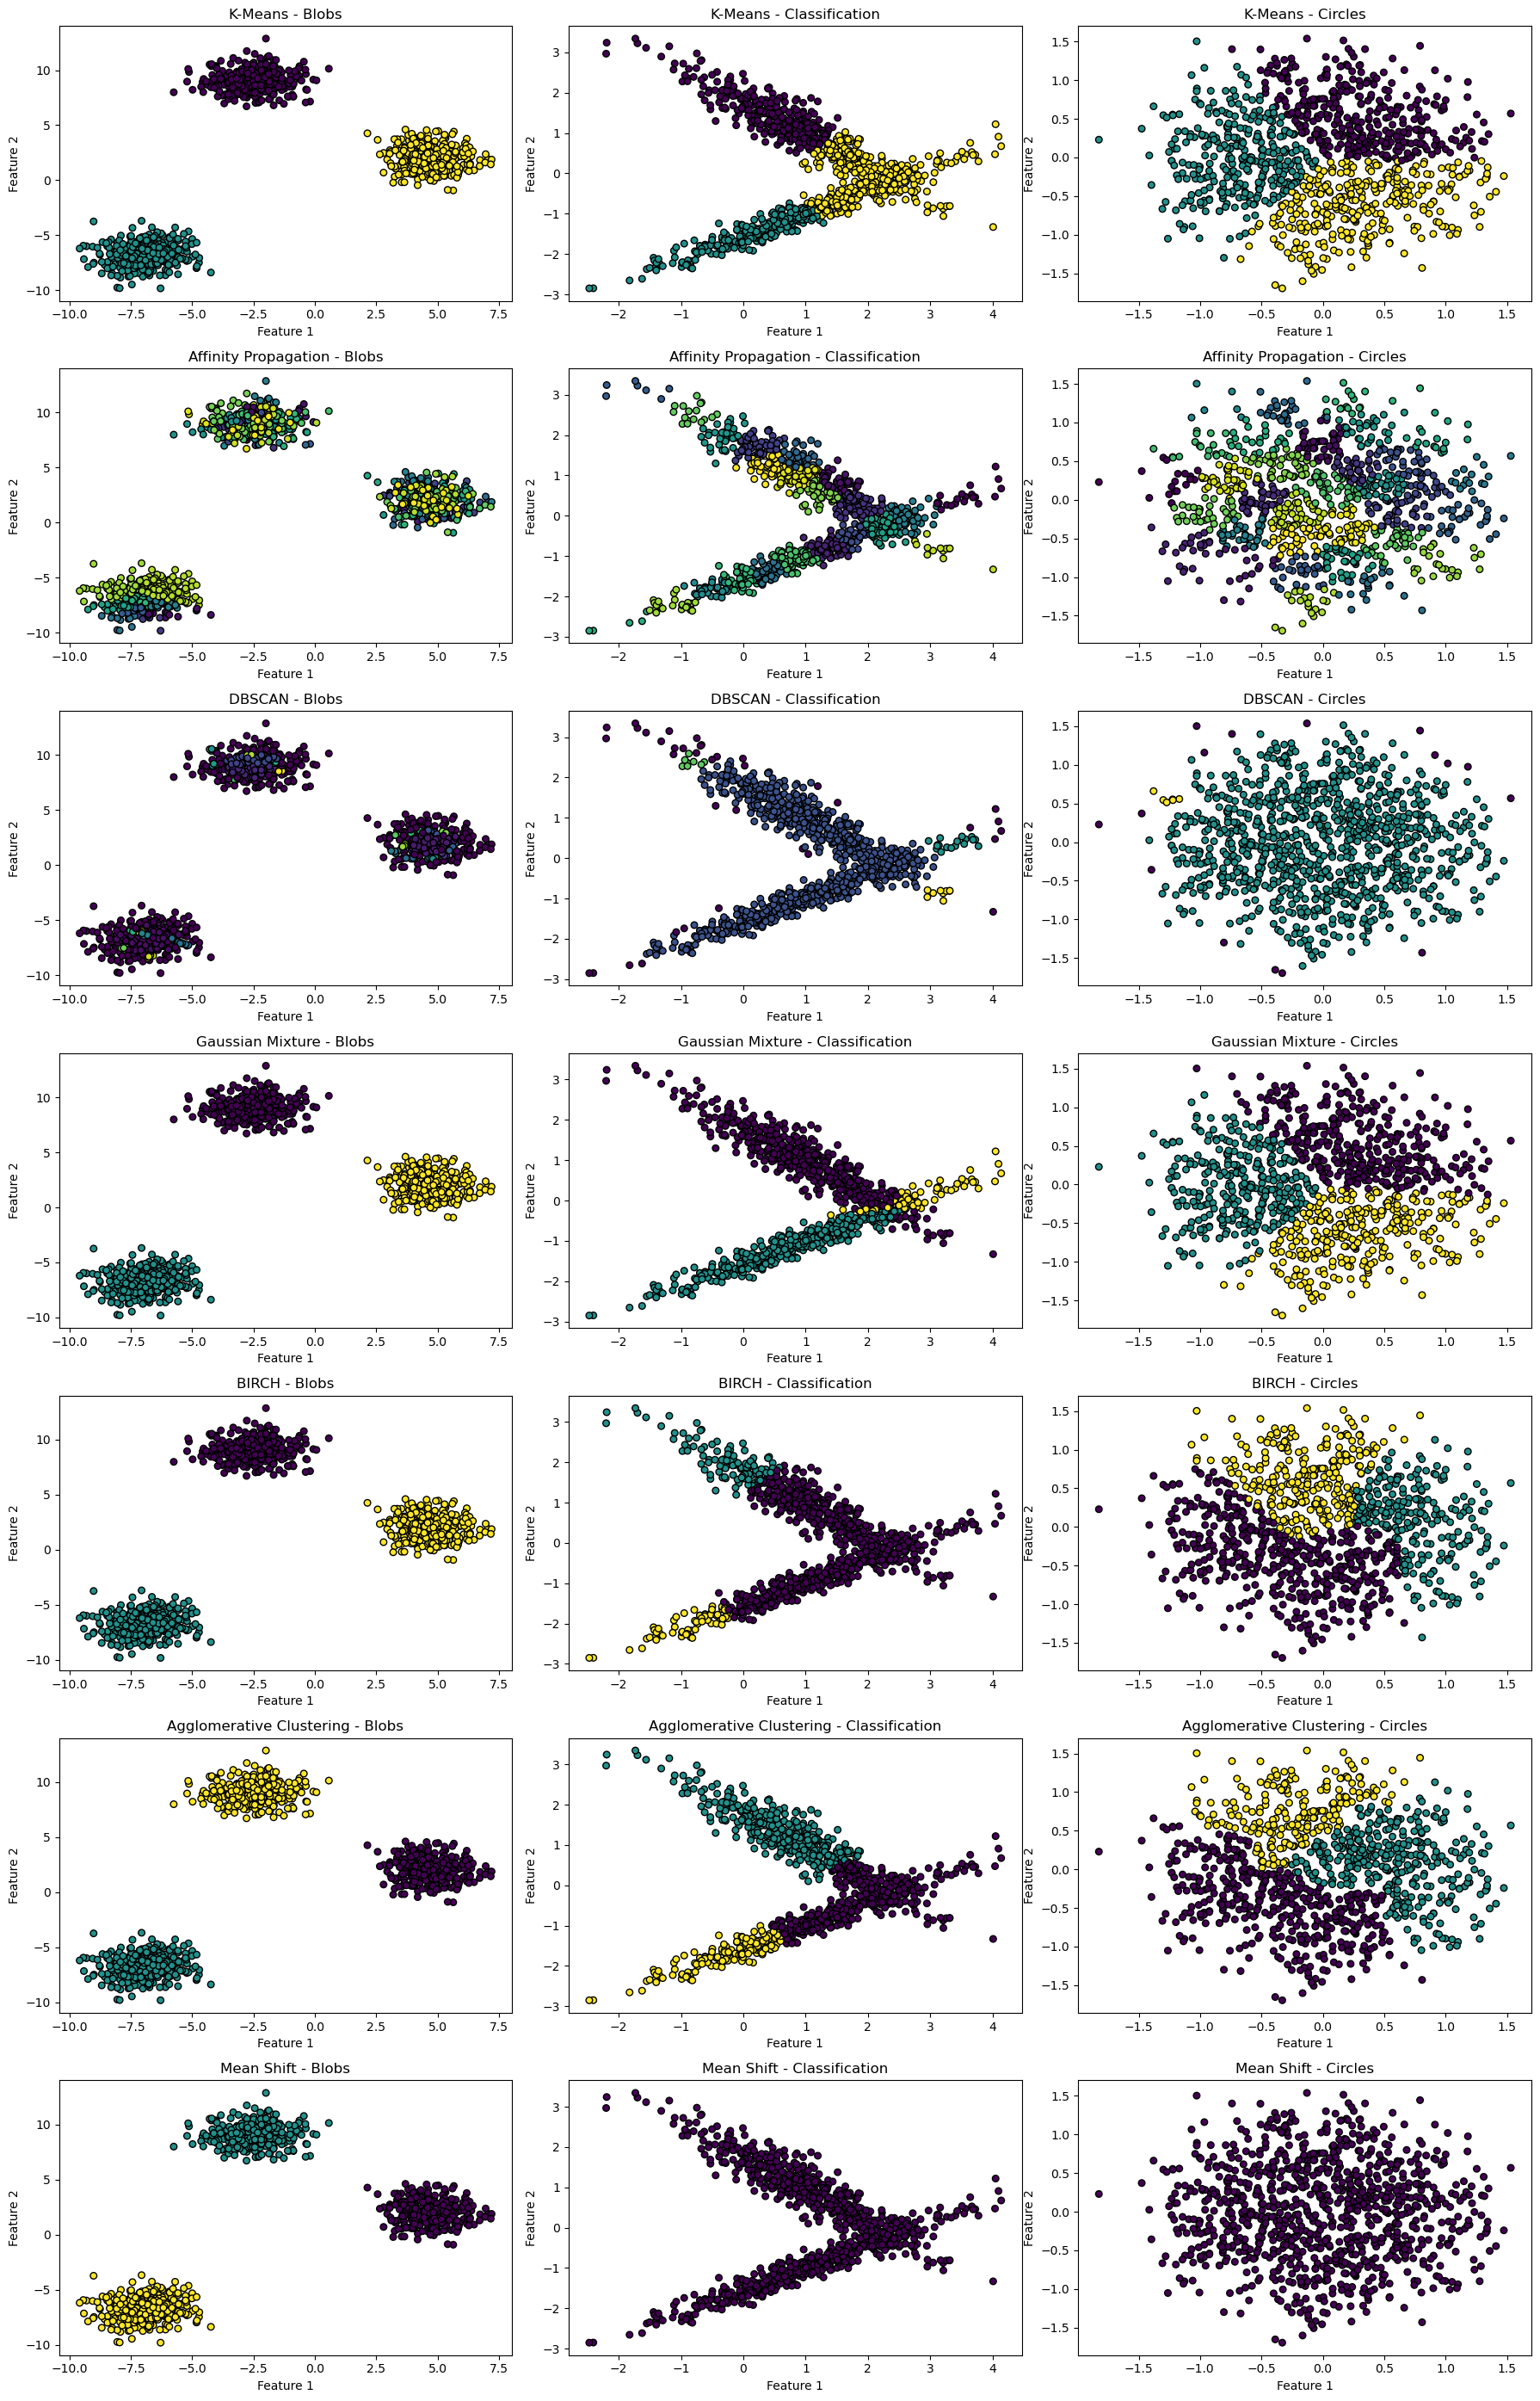

<Figure size 640x480 with 0 Axes>

In [7]:
#task 2
#import libraires
from sklearn.datasets import make_blobs, make_classification, make_circles
from sklearn.cluster import KMeans, AffinityPropagation, DBSCAN, AgglomerativeClustering, MeanShift, Birch
from sklearn.mixture import GaussianMixture

#set seed
np.random.seed(42)

#generate datasets
datasets = {
    "Blobs": make_blobs(n_samples=1000, centers=3, cluster_std=1.0, random_state=42),
    "Classification": make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42),
    "Circles": make_circles(n_samples=1000, factor=0.5, noise=0.3, random_state=42)
}
#clustering alogrithims
clustering_algorithms = {
    "K-Means": KMeans(n_clusters=3, random_state=42),
    "Affinity Propagation": AffinityPropagation(random_state=42),
    "DBSCAN": DBSCAN(eps=0.2),
    "Gaussian Mixture": GaussianMixture(n_components=3, random_state=42),
    "BIRCH": Birch(n_clusters=3),
    "Agglomerative Clustering": AgglomerativeClustering(n_clusters=3),
    "Mean Shift": MeanShift()
}

fig, axes = plt.subplots(len(clustering_algorithms), len(datasets), figsize=(18, 28))
fig.subplots_adjust(hspace=0.5, wspace=0.5)

#loop. through clustering alogrithims and dataset
for clf_idx, (clf_name, algorithm) in enumerate(clustering_algorithms.items()):
    for ds_idx, (ds_name, (X, y)) in enumerate(datasets.items()):
        #fit clustering alogirthim
        if clf_name == "Gaussian Mixture":
            y_pred = algorithm.fit_predict(X)
        else:
            y_pred = algorithm.fit_predict(X)
            
        #plot    
        axes[clf_idx, ds_idx].scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=30, edgecolor='k')
        axes[clf_idx, ds_idx].set_title(f"{clf_name} - {ds_name}")
        axes[clf_idx, ds_idx].set_xlabel("Feature 1")
        axes[clf_idx, ds_idx].set_ylabel("Feature 2")
        
#display plots
plt.tight_layout()
plt.show()
#save plot
plt.savefig('cluster.png')

The results of the clustering algorithms applied to the three datasets show the strength and limitations of each method. K-means clustering performs well on the Blobs dataset as clusters are clearly separable and spherical but it struggles with the circles dataset where clusters are not lineraly seperable, resulting in poor performance. Affinity propagation which doesn't require specifying the number of clustres adapts well to different datasets but can produce noisy and less clear clusters. This is particulary visible in the circles dataset, likely due to its sensitivity to the similarity matrix. DBSCAN effectivly identifies core samples and outliers handling noise in the circles dataset better than k-means but uts performance on the classifcaiton dataset shows its sensitivity to parameter tuning (eps and min_samples), as it fails to cluster the data effectivly. The Gaussian mexture model, which assumes clusters follow a gaussian distribution, captures the cluster strucutre in the blobs and classification datasets well but struggles with the non-gaussian clusters in the circles dataset. BIRCH, which is efficient for large datasets, performs similarly to K-Means but tens to create more compact clusters. Agglomerative clustering performs well on datastes with distinct cluster boundaries, like blobs, but is less effective on circles, which has overlapping clusters. Finally, mean shift, which does not require specifying the number of clusters, performs well on blobs and classification but like DBSCAN it performs poorly on circles due to the limitations in sensitivirty to the bandwith parameter. Overall, each algoritm has its strength depending on the data characteristics. Algorithims such as K-means and GMM are effective when clusters are separated and spherical while DBSCAN and mean shift are more flexible but require carful paramter tuning. Affinity propagation and agglomerative clustering offer flexibility but can struggle with more complex cluster shapes. 